In [1]:
import pandas as pd              
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd   

# Clases propias
from SignalClases import FiltSignal
from SignalClases import IndSW
from Hilbert import HilbClass
from ExtraClases import Extraclases
from Rectification import recClass
from SignalClases import saveData
from SignalClases import saveDataSR
from Wavelet import Wavelet
from SignalClases import saveWV
from SignalClases import saveWVOrg
from SignalClases import OrgSignal

In [2]:
# Datos generales 
numFol = 4                                                                                  # 4 carpetas diferentes 
totFiles = [8,4,8,8]                                                                        # Archivos totales de cada capeta CBX, NaCl, QUININA, TMA

numLabel = 8
srate = 10000

In [ ]:
# for fold in range(numFol):                                                                # Recorrer carpetas
for fold in range(0,numFol):   
          
    # for file in range(totFiles[fold]):                                                    # Recorrer archivos 
    for file in range(totFiles[fold]):   
        
        foldNum = fold             # CBX
        fileNum = file             # FR - 94
        
        
        filtSig,filtPath,fileName = FiltSignal.getData(foldNum,fileNum)                     # Señal Filtrada   250 - 550 Hz
        fileName = fileName[:-2]

        # for label in range(numLabel):
        for label in range(numLabel):
            lst = []                                                                        ## Guardar los elementos detectados como verdaderos FR por electrodo 
            
            indSW,labelInd = IndSW.getData(foldNum,fileNum,label)                           # Fragmentos de indices de SWR 
            
            indSize = indSW.shape                                                           # indices de SW detectados
            # print(file,label)
            
            # for iSW in range(indSize[0]):
            for iSW in range(indSize[0]):
                            
                startSW = indSW[iSW,0]                                                      # Saber donde comienza el indice SW
                # print(iSW)
                # print(startSW)
                # print(startSW,indSW[iSW,1] )
                
                prubeSignal = (filtSig[label,indSW[iSW,0]:indSW[iSW,1]]*.001).copy()        # copiar la información de la señal con normalizacion a V 
                ampEnv, thold,medT = HilbClass.HBSig(prubeSignal)                           # Indicar treshold y midthreshold
                recTr = recClass.recThold(prubeSignal)    
                
                crossDet = Extraclases(ampEnv,thold,medT)                                   # Crear objeto 
                pre, post = crossDet.cross10ms()
                # print('pre cross 10',pre)
                # print('pre cross 10',post)
                if len(pre) == 0:
                    continue
                else:
                    for p in range(len(pre)):
                        signal = prubeSignal[pre[p]:post[p]]
                        peaks = recClass.rectSignal(signal,recTr) 
                        if len(peaks) >= 6:
                            pre[p] += startSW                                               # Regresar a índice de señal filtrada orignal
                            post[p] += startSW
                            # print('Rec pre :',pre)
                            # print('Rec post :',post)
                            lapse = (post[p]-pre[p])/srate                                  # Duración aprox de evento
                            lsTemp = [fileName,labelInd,label,indSW[iSW,0],indSW[iSW,1],pre[p],post[p],lapse]   # Lista temporal para agregar a la lista principal
                            lst.append(lsTemp)                                              # lista principal                  
                        else:
                            continue
                    
            df1 = pd.DataFrame(lst, columns=['File Name','Electrode Name','Electrode index','indSW start','indSW end','indFR star ','indFR end','Duration'])
            pathSV = saveData.getData(foldNum,fileNum,label)
            df1.to_csv(pathSV,sep=',',index=False)     

In [ ]:
plt.plot(ampEnv)

## Manejo de df

In [2]:
numFol = 4                                                                                  # 4 carpetas diferentes 
totFiles = [8,4,8,8]                                                                        # Archivos totales de cada capeta CBX, NaCl, QUININA, TMA

numLabel = 8

In [ ]:
## Eliminar registros duplicados SW 
for fold in range(4):
    for file in range(totFiles[fold]):
        for lb in range(8):
            dataPath = saveData.getData(fold, file, lb)       # carga de dataset inicial 
            df = pd.read_csv(dataPath)
            df = df.drop_duplicates(subset=['indFR end'])
            pathSV = saveDataSR.getData(fold, file,lb)
            df.to_csv(pathSV,sep=',',index=False)  

# Wavelets

### Calculo solo de wavelets


In [1]:
import pandas as pd              
import numpy as np
 
# Clases propias
from SignalClases import FiltSignal
from SignalClases import OnlyWv
from SignalClases import saveDataSR
from Wavelet import Wavelet
from SignalClases import saveWV


In [2]:
numFol = 4                                                                                  # 4 carpetas diferentes 
totFiles = [8,4,8,8]                                                                        # Archivos totales de cada capeta CBX, NaCl, QUININA, TMA

numLabel = 8
srate = 10000

elcNames = ['HAD1', 'HADP2', 'HAD3', 'HADp4', 'HPD5', 'HPDp6','HPD7', 'HPDp8']

In [ ]:
# for fold in range(numFol):
for fold in range(numFol):
    
    # for file in range(totFiles[fold]):
    for file in range(totFiles[fold]):
        
        filtSig,filtPath,fileName = FiltSignal.getData(fold,file)                               # Carga de data filtrada 
        print(filtPath)
        for lb in range(numLabel):            
        # for lb in range(2,8):
            
            filtSiglb = (filtSig[lb, :]).copy() 
            dataPath = saveDataSR.getData(fold,file,lb)  
            df = pd.read_csv(dataPath)
            start = df["indFR star "].to_numpy()
            end = df["indFR end"].to_numpy()
            # start = df["indFR I"].to_numpy()
            # end = df["indFR F"].to_numpy()
           
            for fr in range(len(start)):
                signalWavelet = filtSiglb[(start[fr])-500:(end[fr])+500]               
                time,frex,mWarr = Wavelet.getWavelet(signalWavelet)
                pathIm = saveWV.getData(fold,file,lb,elcNames[lb],str(start[fr]),str(end[fr]))
                pathFile = OnlyWv.getData(fold,file,lb,elcNames[lb],str(start[fr]),str(end[fr]))
                np.savez(pathFile, time = time, frex = frex, mWarr = mWarr, pathIm= pathIm)
                
                
                
                

S:\\Proyecto Epilepsia\\Base de datos filtrada\\CBX_f\\FR-77_CBX_f\\FR-77_CBX_f.mat
S:\\Proyecto Epilepsia\\Base de datos filtrada\\CBX_f\\FR-78_CBX_f\\FR-78_CBX_f.mat
S:\\Proyecto Epilepsia\\Base de datos filtrada\\CBX_f\\FR-80_CBX_f\\FR-80_CBX_f.mat
S:\\Proyecto Epilepsia\\Base de datos filtrada\\CBX_f\\FR-84_CBX_f\\FR-84_CBX_f.mat
S:\\Proyecto Epilepsia\\Base de datos filtrada\\CBX_f\\FR-90_CBX_f\\FR-90_CBX_f.mat
S:\\Proyecto Epilepsia\\Base de datos filtrada\\CBX_f\\FR-94_CBX_f\\FR-94_CBX_f.mat
S:\\Proyecto Epilepsia\\Base de datos filtrada\\CBX_f\\FR-95_CBX_f\\FR-95_CBX_f.mat


## Wavelet images


In [21]:
import os
import matplotlib.pyplot as plt
from matplotlib import cm

In [8]:
dirName = r"S:\Proyecto Epilepsia\Only_Wavelet\experimental CBX proyecto\FR-77_CBX\HAD1"  ## Carpeta donde se encuentran ubicados todos los archivos 
names = os.listdir(dirName)   # Nombres de los archivos a trabajar 
print(names)
print(len(names))

['FR-77_CBX_HAD1-1014394-1014559.npz', 'FR-77_CBX_HAD1-1058471-1058648.npz', 'FR-77_CBX_HAD1-1058473-1058647.npz', 'FR-77_CBX_HAD1-1116084-1116300.npz', 'FR-77_CBX_HAD1-1125157-1125231.npz', 'FR-77_CBX_HAD1-1125469-1125539.npz', 'FR-77_CBX_HAD1-1126483-1126791.npz', 'FR-77_CBX_HAD1-127388-127463.npz', 'FR-77_CBX_HAD1-1353536-1353672.npz', 'FR-77_CBX_HAD1-1360750-1360842.npz', 'FR-77_CBX_HAD1-1362260-1362389.npz', 'FR-77_CBX_HAD1-1446556-1446738.npz', 'FR-77_CBX_HAD1-1447053-1447133.npz', 'FR-77_CBX_HAD1-1481089-1481325.npz', 'FR-77_CBX_HAD1-1491565-1491661.npz', 'FR-77_CBX_HAD1-1493215-1493297.npz', 'FR-77_CBX_HAD1-1774895-1774985.npz', 'FR-77_CBX_HAD1-1777656-1777739.npz', 'FR-77_CBX_HAD1-1814060-1814202.npz', 'FR-77_CBX_HAD1-1820037-1820324.npz', 'FR-77_CBX_HAD1-1820502-1820620.npz', 'FR-77_CBX_HAD1-1820504-1820619.npz', 'FR-77_CBX_HAD1-1821297-1821403.npz', 'FR-77_CBX_HAD1-1821598-1821731.npz', 'FR-77_CBX_HAD1-1821602-1821730.npz', 'FR-77_CBX_HAD1-1821983-1822074.npz', 'FR-77_CBX_HA

In [11]:
totDir = dirName +'\\'+'\\' + names[0]
totDir

'S:\\Proyecto Epilepsia\\Only_Wavelet\\experimental CBX proyecto\\FR-77_CBX\\HAD1\\\\FR-77_CBX_HAD1-1014394-1014559.npz'

In [12]:
data = np.load(totDir)

In [17]:
time = data['time']
frex = data['frex']
mWarr = data['mWarr']
pathIm = data['pathFile'].item()

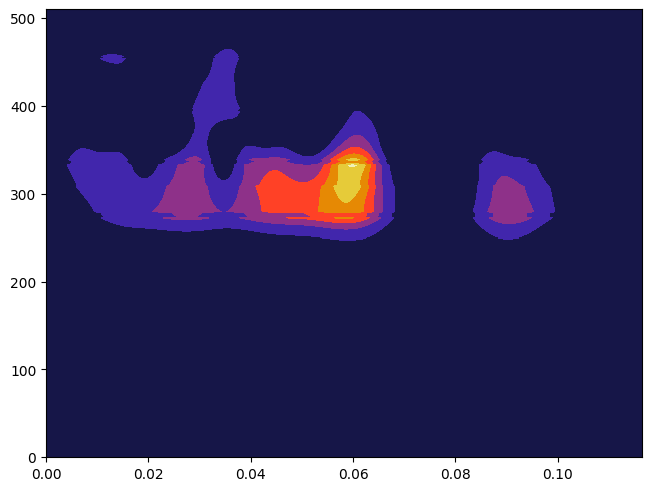

In [22]:
fig, ax = plt.subplots(layout='constrained')
CS = ax.contourf(time,frex,mWarr,cmap=cm.CMRmap)

In [23]:
pathIm

'S:\\\\Proyecto Epilepsia\\\\Wavelet_Images_New_Filter\\\\experimental CBX proyecto\\\\FR-77_CBX\\\\HAD1\\FR-77_CBX_HAD1-1014394-1014559.png'

In [1]:
import pandas as pd              
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd   

# Clases propias
from SignalClases import FiltSignal
from SignalClases import IndSW
from Hilbert import HilbClass
from ExtraClases import Extraclases
from Rectification import recClass
from SignalClases import saveData
from SignalClases import saveDataSR
from Wavelet import Wavelet
from SignalClases import saveWV
from SignalClases import saveWVOrg
from SignalClases import OrgSignal

In [2]:
### Wavelet Images

numFiles1 = [0,3,6,7] # 77 CBX, 91 NaCl, 94 QUININA, 50 TMA

numFiles2 = [3,1,2,0] # 84 CBX, 83 NaCl, 79 QUININA, 35 TMA

numFiles3 = [6,2,4,3] # 95 CBX, 89 NaCl, 84 QUININA, 91 TMA



In [3]:
cbx_77 =  [667, 1486, 507, 1016, 242, 496, 1389, 645]
cbx_84 =  [746, 928, 845, 474, 103, 446, 917, 1162]
cbx_95 =  [910, 679, 851, 1233, 1099, 764, 631, 592]


nacl_83 = [1564, 1395, 1343, 1790, 1073, 1018, 1436, 1162 ]
nacl_89 = [5, 24, 11, 40, 55, 100, 32, 159]
nacl_91 = [47, 58, 464, 655, 298, 46, 63, 642]

quinina_79 = [745, 269, 376, 132, 539, 162, 217, 766] 
quinina_84 = [424, 491, 868, 167, 59, 136, 486, 547]   # quinina empezar desde lb 3
quinina_94 = [564, 184, 941, 320, 373, 123, 136, 624] 

tma_35 = [438, 196, 598, 276, 251, 125, 206, 136] 
tma_91 = [53, 9, 206, 74, 34, 19, 10, 56] 
tma_50 = [101, 255, 153, 286, 149, 295, 234, 117] 


regA = [cbx_77, nacl_83, quinina_79,tma_35]

regB = [cbx_84, nacl_89, quinina_84,tma_91]

regC = [cbx_95, nacl_91, quinina_94,tma_50]

In [4]:
for a in range(0,1):                      # 0,totFold hasta 4
    foldNum = a                #  0 -> CBX, 1-> NaCl, 2 -> QUININA, 3-> TMA
    fileNum = numFiles3[a]             
    
    filtSig , filtPath ,fileName = FiltSignal.getData(foldNum,fileNum)           # Carga de señal filtrada mediante path, forlnum -> folder, y fileNum -> num de archivo 
    print(filtPath)
    
    for l in range(5,8):                        # 0,8 -> electrodos 
        lb = l
        dataPath  = saveDataSR.getData(foldNum,fileNum,lb)
        print(dataPath)
        df = pd.read_csv(dataPath)
        # sz = df.shape
        nReg = regC[a][l]
        for i in range(0,nReg):                # 0,sz[0]  H1 -> 0-1133
            inPnt = int(df.at[i,'indFR star '])         # Indices encontrados de las FR
            fnPnt = int(df.at[i,'indFR end'])
            filtCop = filtSig[lb,(inPnt-500):(fnPnt+500)].copy()
            time,frex,mWarr = Wavelet.getWavelet(filtCop)
            fig, ax = plt.subplots(layout='constrained')
            CS = ax.contourf(time,frex,mWarr,cmap=cm.CMRmap)
            plt.gca().set_axis_off()
            pathIm = saveWV.getData(foldNum,fileNum,lb,str(i),str(inPnt),str(fnPnt))
            # print(pathIm)
            fig.savefig(pathIm)
            plt.close(fig)
            del time,frex,mWarr,filtCop,inPnt,fnPnt
            
    del filtSig, filtPath,fileName

S:\\Proyecto Epilepsia\\Base de datos filtrada\\CBX_f\\FR-95_CBX_f\\FR-95_CBX_f.mat
S:\\Proyecto Epilepsia\\DataFramesNew_SR\\experimental CBX proyecto\\FR-95_CBX\\HPDp6\FR-95_CBX_HPDp6_SR.csv


KeyboardInterrupt: 

In [ ]:
nReg

In [ ]:

# lst=[]

for fold in range(3,4):
    
    # for file in range(totFiles[fold]):
    for file in range(totFiles[fold]):
        print(file)
        lst = []       
        for lb in range(numLabel):            
        # for lb in range(2,8):
            
            dataPath = saveDataSR.getData(fold,file,lb)  
            df = pd.read_csv(dataPath)
            start = df["indFR star "].to_numpy()
            lst.append(len(start)-1)
        print(lst)           

In [16]:
# Folder
numFol = 4                                                                                  # 4 carpetas diferentes 
totFiles = [8,4,8,8]                                                                        # Archivos totales de cada capeta CBX, NaCl, QUININA, TMA

numLabel = 8
srate = 10000

elcNames = ['HAD1', 'HADP2', 'HAD3', 'HADp4', 'HPD5', 'HPDp6','HPD7', 'HPDp8']

Grafica de muestra para true y false ripple

In [ ]:
import numpy as np 

fold = 0 
file = 6

filtSig,filtPath,fileName = FiltSignal.getData(fold,file)                               # Carga de data filtrada 
orgSignal, path, fileOrg = OrgSignal.getData(fold,file)     

srate = 10000
szOrg = orgSignal.shape
timevec = np.arange(0,szOrg[1],1)/srate  ## Vector de tiempo

In [ ]:
## Calculo wavelet  true FR 
lb = 1
filtSiglb = (filtSig[lb, :]*.001).copy() 

dataPath = saveData.getData(fold,file,lb)  
df = pd.read_csv(dataPath)
start = df["indFR star "].to_numpy()
end = df["indFR end"].to_numpy()

signalWavelet = filtSiglb[(start[-4]-500):(end[-4]+500)]
timeT,frexT,mWarrT = Wavelet.getWavelet(signalWavelet)

In [ ]:
## Grafica compuesta 

fig, axs = plt.subplots(3, sharex=True,figsize=(8,8), dpi=300)
axs[0].plot(timevec[(start[-4]-500):(end[-4]+500)],orgSignal[lb,(start[-4]-500):(end[-4]+500)], color = 'g')    # Señal Orginal
axs[0].set_title('Raw Signal',fontsize = 12, fontweight ="bold")


axs[1].plot(timevec[(start[-4]-500):(end[-4]+500)],filtSig[lb,(start[-4]-500):(end[-4]+500)]*.001, color = 'b')   # Señal band pass 250-500 Hz
axs[1].set_title('Filter Signal (250 -500 Hz)',fontweight ="bold", fontsize = 12)
# plt.ylim(-0.2,0.2)

axs[2].contourf(timevec[(start[-4]-500):(end[-4]+500)],frexT,mWarrT,cmap=cm.CMRmap)
axs[2].set_title('Time-Frequency Spectrum',fontweight ="bold", fontsize = 12)
axs[2]. set_ylim(150, 500)

# -------------------BEGIN-CHANGES------------------------
# Hide the all but the bottom spines (axis lines)
axs[0].spines["right"].set_visible(False)
axs[0].spines["left"].set_visible(False)
axs[0].spines["top"].set_visible(False)

axs[1].spines["right"].set_visible(False)
axs[1].spines["left"].set_visible(False)
axs[1].spines["top"].set_visible(False)

axs[2].spines["right"].set_visible(False)
axs[2].spines["left"].set_visible(False)
axs[2].spines["top"].set_visible(False)

fig.text(0.5, 0.04, 'Time (s)', ha='center', va='center')
fig.text(0.06, 0.5, 'Amplitude (V)', ha='center', va='center', rotation='vertical')
fig.text(0.06, 0.8, 'Amplitude (V)', ha='center', va='center', rotation='vertical')
fig.text(0.06, 0.2, 'Frecuency (Hz)', ha='center', va='center', rotation='vertical')

In [ ]:
## Calculo wavelet false FR

lb = 0
filtSiglb = (filtSig[lb, :]).copy() 

dataPath = saveData.getData(fold,file,lb)  
df = pd.read_csv(dataPath)
start = df["indFR star "].to_numpy()
end = df["indFR end"].to_numpy()

signalWavelet = filtSiglb[(start[10]-500):(end[10]+500)]
timeF,frexF,mWarrF = Wavelet.getWavelet(signalWavelet)



In [ ]:
## Grafica compuesta 

fig, axs = plt.subplots(3, sharex=True,figsize=(8,8), dpi=300)
axs[0].plot(timevec[(start[10]-500):(end[10]+500)],orgSignal[lb,(start[10]-500):(end[10]+500)], color = 'g')    # Señal Orginal
axs[0].set_title('Raw Signal',fontsize = 12, fontweight ="bold")


axs[1].plot(timevec[(start[10]-500):(end[10]+500)],filtSig[lb,(start[10]-500):(end[10]+500)]*.001, color = 'b')   # Señal band pass 250-500 Hz
axs[1].set_title('Filter Signal (250 -500 Hz)',fontweight ="bold", fontsize = 12)
# plt.ylim(-0.2,0.2)

axs[2].contourf(timevec[(start[10]-500):(end[10]+500)],frexF,mWarrF,cmap=cm.CMRmap)
axs[2].set_title('Time-Frequency Spectrum',fontweight ="bold", fontsize = 12)
axs[2]. set_ylim(150, 500)

# -------------------BEGIN-CHANGES------------------------
# Hide the all but the bottom spines (axis lines)
axs[0].spines["right"].set_visible(False)
axs[0].spines["left"].set_visible(False)
axs[0].spines["top"].set_visible(False)

axs[1].spines["right"].set_visible(False)
axs[1].spines["left"].set_visible(False)
axs[1].spines["top"].set_visible(False)

axs[2].spines["right"].set_visible(False)
axs[2].spines["left"].set_visible(False)
axs[2].spines["top"].set_visible(False)

fig.text(0.5, 0.04, 'Time (s)', ha='center', va='center')
fig.text(0.06, 0.5, 'Amplitude (V)', ha='center', va='center', rotation='vertical')
fig.text(0.06, 0.8, 'Amplitude (V)', ha='center', va='center', rotation='vertical')
fig.text(0.06, 0.2, 'Frecuency (Hz)', ha='center', va='center', rotation='vertical')

In [ ]:
for fold in range(numFol):
# for fold in range(3,4):
    
    for file in range(totFiles[fold]):
    # for file in range(2,totFiles[fold]):
        
        orgSignal, path, fileOrg = OrgSignal.getData(fold,file)                               # Carga de data filtrada 
        
        for lb in range(numLabel):            
        # for lb in range(2,8):
            
            orgSignalb = (orgSignal[lb, :]).copy() 
            
            dataPath = saveData.getData(fold,file,lb)  
            df = pd.read_csv(dataPath)
            start = df["indFR star "].to_numpy()
            end = df["indFR end"].to_numpy()
            
            for fr in range(len(start)):
                signalWavelet = orgSignalb[(start[fr]-500):(end[fr]+500)]
                time,frex,mWarr = Wavelet.getWavelet(signalWavelet)
                fig, ax = plt.subplots(layout='constrained')
                CS = ax.contourf(time,frex,mWarr,cmap=cm.CMRmap)
                plt.gca().set_axis_off()
                pathIm = saveWVOrg.getData(fold,file,lb,elcNames[lb],str(start[fr]),str(end[fr]))
                print(pathIm)
                plt.close(fig)
                fig.savefig(pathIm)   




In [ ]:
file

In [ ]:
dataPath = saveData.getData(fold,file,lb) 

In [ ]:
numFol = 4                                                                                  # 4 carpetas diferentes 
totFiles = [8,4,8,8]                                                                        # Archivos totales de cada capeta CBX, NaCl, QUININA, TMA

numLabel = 8
srate = 10000

In [ ]:
Foldnum =  0 
FileNum = 5
lb= 0

## Cargar señal 
filtSig,filtPath,fileName = FiltSignal.getData(Foldnum,FileNum )

filtSig = filtSig[lb, :]    # Se toma el registro completo de signal 


In [ ]:
# Cargar data frame
dataPath = saveData.getData(Foldnum, FileNum, lb)  
df = pd.read_csv(dataPath)
df

In [ ]:
start = df["indFR star "].to_numpy()
print("start",start)
end = df["indFR end"].to_numpy()
print("end",end)

In [7]:
signalWavelet = filtSig[(start[0]-500):(end[0]+500)]
time,frex,mWarr = Wavelet.getWavelet(signalWavelet)
fig, ax = plt.subplots(layout='constrained')
CS = ax.contourf(time,frex,mWarr,cmap=cm.CMRmap)
plt.gca().set_axis_off()
# pathIm = saveWV.getData(foldNum,fileNum,lb,str(i),str(inPnt),str(fnPnt))
# plt.close(fig)

# Programa individual

In [ ]:
import pandas as pd              
import matplotlib.pyplot as plt
from matplotlib import cm
import pandas as pd   

# Clases propias
from SignalClases import OrgSignal
from SignalClases import FiltSignal
from SignalClases import SWSignal
from SignalClases import IndSW
from Hilbert import HilbClass
from ExtraClases import Extraclases
from Rectification import recClass

In [ ]:
##  Cargar una muestra para prueba
foldNum = 0             # CBX
fileNum = 5             # FR - 94
srate = 10000           # tasa de muestreo 

# Original Signal 
# orgSignal, path, file = OrgSignal.getData(foldNum,fileNum)    # Señal original 
 
## Señal Filtrada   250 - 550 Hz
filtSig,filtPath = FiltSignal.getData(foldNum,fileNum)           # Señal Filtrada

## Señal Slow Wave 
# SWSig = SWSignal.getData(foldNum,fileNum)               # Señal filtrada para detección de ondas lentas 

## Indice de SW
label = 0
indSW,labelInd = IndSW.getData(foldNum,fileNum,label)   # Fragmentos de indices de SWR 
indSize = indSW.shape     # Indica cuantos indices de slow wave se encontraron en signal
print("indSize: ",indSize)

In [ ]:
idxSW = 0                      # 0- hasta tantas SW se hayan encontrado 
print(indSW[idxSW,0])           #  primeros indices de swr detectados [fila, columna]
print(indSW[idxSW,1])
startSW = indSW[idxSW,0]        # indice de inicio de onda lenta    

# Extracción de señal en fragmento de interés
prubeSignal = (filtSig[label,indSW[idxSW,0]:indSW[idxSW,1]]*.001).copy()    # copiar la información de la señal con normalizacion a V 
ampEnv, thold,medT = HilbClass.HBSig(prubeSignal)                           # Indicar treshold y midthreshold
recTr = recClass.recThold(prubeSignal)                                      # Threshold de rectificación  para onda en fragmento SW  

In [ ]:
crossDet = Extraclases(ampEnv,thold,medT)     # Crear objeto 
pre, post = crossDet.cross10ms()
print(pre, post)  # Determinar cruses de interes, 
print(type(pre))

In [ ]:
pre[0] += startSW
pre

In [13]:
signal = prubeSignal[pre[0]:post[0]]

peaks = recClass.rectSignal(signal,recTr) 

### Wavelet Images
numFiles2 = [3,1,2,0] # 84 CBX, 83 NaCl, 79 QUININA, 35 TMA
numFiles3 = [6,2,4,3] # 95 CBX, 89 NaCl, 84 QUININA, 91 TMA
numFiles1 = [0,3,6,7] # 77 CBX, 91 NaCl, 94 QUININA, 50 TMA

## Graficas de utilidad 

In [ ]:
### Plot de las señales  (Original, filtrada SW, filtrada FR)
numInd = 0   ## No. de SW 

# Grafica señal original
fig, axs = plt.subplots(3, sharex=True,figsize=(10,7))
axs[0].plot(timevec[indSW[numInd,0]:indSW[numInd,1]],orgSignal[label,indSW[numInd,0]:indSW[numInd,1]],label='Original Signal')    # Señal Orginal
axs[0].set_title('Original Signal')
axs[0].set_title('95_CBX', loc='right', style = "italic")
axs[1].plot(timevec[indSW[numInd,0]:indSW[numInd,1]],SWSig[label,indSW[numInd,0]:indSW[numInd,1]], label= 'Slow Wave filtering Signal')  # Senal Slow Wave
axs[1].set_title('Slow Wave filtering Signal')
axs[2].plot(timevec[indSW[numInd,0]:indSW[numInd,1]],filtSig[label,indSW[numInd,0]:indSW[numInd,1]]*.001, label= 'Band Pass Signal (250 -500 Hz)')   # Señal band pass 250-500 Hz
axs[2].set_title('Band Pass Signal (250 -500 Hz)')

axs[0].spines["right"].set_visible(False)
axs[0].spines["left"].set_visible(False)
axs[0].spines["top"].set_visible(False)

axs[1].spines["right"].set_visible(False)
axs[1].spines["left"].set_visible(False)
axs[1].spines["top"].set_visible(False)

axs[2].spines["right"].set_visible(False)
axs[2].spines["left"].set_visible(False)
axs[2].spines["top"].set_visible(False)

fig.text(0.5, 0.04, 'Time (s)', ha='center', va='center')
fig.text(0.06, 0.5, 'Amplitude (V)', ha='center', va='center', rotation='vertical')

In [127]:
import numpy as np

szOrg = orgSignal.shape
timevec = np.arange(0,szOrg[1],1)/srate  ## Vector de tiempo
t = timevec[indSW[idxSW,0]:indSW[idxSW,1]]

crossDet = Extraclases(ampEnv,thold,medT) 

In [124]:
## Cruce de threshold 
pre, post = crossDet.thresholdCrossing()
premid, postmid = crossDet.midThresCross()
pre10, post10 = crossDet.cross10ms()

In [ ]:
fig = plt.figure(figsize=(10,10))
axs = fig.add_subplot(1,1,1)
# axs.plot(t, sigWT, label = 'Filter signal')     # Señal con la extracción del threshold
axs.plot(t , prubeSignal, label = 'Filter Signal',marker=".")           # Envoltura menos el thold 
axs.plot(t , ampEnv, label = 'Envelope', marker=".")           # Envoltura menos el thold 
axs.axhline(y = thold, color='r',linestyle=':', label='Threshold')         # thold pasa a ser 0
axs.axhline(y = medT, color='g',linestyle='--', label='0.5 Threshold')         # thold pasa a ser 0
axs.scatter(t[pre],ampEnv[pre], color= 'b', marker="s", label= 'Threshold point',s=80) 
axs.scatter(t[post],ampEnv[post],color= 'b', marker="s",s=80)
axs.scatter(t[premid],ampEnv[premid],color= 'r', marker="s",s=80) 
axs.scatter(t[postmid],ampEnv[postmid],color= 'r', marker="s",label= '0.5 Threshold point',s=80) 
axs.spines["right"].set_visible(False)
axs.spines["left"].set_visible(False)
axs.spines["top"].set_visible(False)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")

plt.legend(loc='lower center',frameon=True ,ncol=3,labelspacing=0.1)
axs.set_xlim([10.27,10.3])
axs.set_ylim([-0.1,0.105])

### Rectificación de onda

In [168]:
## 
signal = prubeSignal[pre10[0]:post10[0]]
absSignal = np.fabs(prubeSignal[pre10[0]:post10[0]])

t = timevec[indSW[idxSW,0]:indSW[idxSW,1]]
t = t[pre10[0]:post10[0]]

In [ ]:



fig = plt.figure(figsize=(10,10))
axs = fig.add_subplot(1,1,1)
axs.plot(t, signal, label = 'Filter signal',marker=".")
axs.plot(t, absSignal, label = 'Rectified signal',marker=".")
axs.axhline(y = recTr, color='m',linestyle='--', label='Threshold background')
axs.axhline(y = 0, color='r',linestyle='-.', label='0 V')
axs.scatter(t[peaks],abs(signal[peaks]),marker=7,s=100, label="Peaks")
axs.spines["right"].set_visible(False)
axs.spines["left"].set_visible(False)
axs.spines["top"].set_visible(False)


plt.legend(loc='lower center',frameon=True ,ncol=6,labelspacing=0.1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")


In [ ]:
## Caso rechazado de rectificación
print(premid, postmid )

In [177]:
signal = prubeSignal[premid[0]:postmid[0]]
absSignal = np.abs(prubeSignal[premid[0]:postmid[0]])

t = timevec[indSW[idxSW,0]:indSW[idxSW,1]]
t = t[premid[0]:postmid[0]]

In [179]:
from scipy.signal import find_peaks
peaks, _ = find_peaks(abs(signal), height=recTr)

In [ ]:
fig = plt.figure(figsize=(10,10))
axs = fig.add_subplot(1,1,1)
axs.plot(t, signal, label = 'Filter signal',marker=".")
axs.plot(t, absSignal, label = 'Rectified signal',marker=".")
axs.axhline(y = recTr, color='m',linestyle='--', label='Threshold background')
axs.axhline(y = 0, color='r',linestyle='-.', label='0 V')
axs.scatter(t[peaks],abs(signal[peaks]),marker=7,s=100, label="Peaks")
axs.spines["right"].set_visible(False)
axs.spines["left"].set_visible(False)
axs.spines["top"].set_visible(False)


plt.legend(loc='lower center',frameon=True ,ncol=6,labelspacing=0.1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (V)")